In [1]:
"""
STEP 1: Pure descriptive look at the raw DVF data. No filtering, no fixing yet.
Just: load it, look at dtypes, look at distributions (quartiles), look at value_counts
of the categorical columns that matter. Run this locally and paste the full output back.
"""

import os
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PATH = os.environ.get("HARMONIC_DVF_RAW", "./data/processed/dvf_75_92_93_94_2021-2025.parquet")  # override via env var if needed

df = pd.read_parquet(PATH)

print("=" * 90)
print("BASIC SHAPE")
print("=" * 90)
print(f"Rows: {len(df):,}   Columns: {len(df.columns)}")
print(df.dtypes)

print("\n" + "=" * 90)
print("YEARS PRESENT (annee column)")
print("=" * 90)
print(df["annee"].value_counts().sort_index())

print("\n" + "=" * 90)
print("type_local VALUE COUNTS")
print("=" * 90)
print(df["type_local"].value_counts(dropna=False))

print("\n" + "=" * 90)
print("nature_mutation VALUE COUNTS")
print("=" * 90)
print(df["nature_mutation"].value_counts(dropna=False))

print("\n" + "=" * 90)
print("nombre_lots VALUE COUNTS (raw, before any type conversion)")
print("=" * 90)
print(df["nombre_lots"].value_counts(dropna=False).head(20))
print("dtype:", df["nombre_lots"].dtype)

print("\n" + "=" * 90)
print("valeur_fonciere DESCRIBE (all rows, no filtering)")
print("=" * 90)
print(df["valeur_fonciere"].describe())
print("\nQuantiles:")
for q in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]:
    print(f"  {q:>6.1%}: {df['valeur_fonciere'].quantile(q):,.0f}")

print("\n" + "=" * 90)
print("surface_reelle_bati DESCRIBE")
print("=" * 90)
print(pd.to_numeric(df["surface_reelle_bati"], errors="coerce").describe())

print("\n" + "=" * 90)
print("id_mutation: HOW MANY ROWS PER MUTATION? (this is the key diagnostic)")
print("=" * 90)
rows_per_mutation = df.groupby("id_mutation").size()
print(rows_per_mutation.value_counts().sort_index().head(20))
print(f"\nTotal unique mutations: {df['id_mutation'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"Mutations with >1 row: {(rows_per_mutation > 1).sum():,} "
      f"({(rows_per_mutation > 1).mean():.1%} of mutations)")

print("\n" + "=" * 90)
print("TOP 15 HIGHEST valeur_fonciere ROWS -- inspect these by hand")
print("=" * 90)
top15 = df.nlargest(15, "valeur_fonciere")[[
    "id_mutation", "date_mutation", "code_commune", "nom_commune",
    "type_local", "nombre_lots", "valeur_fonciere", "surface_reelle_bati"
]]
print(top15.to_string())

print("\n" + "=" * 90)
print("HOW MANY ROWS SHARE id_mutation WITH ONE OF THOSE TOP 15?")
print("=" * 90)
top15_ids = top15["id_mutation"].tolist()
matching = df[df["id_mutation"].isin(top15_ids)][[
    "id_mutation", "date_mutation", "code_commune", "type_local",
    "nombre_lots", "valeur_fonciere", "surface_reelle_bati"
]].sort_values(["id_mutation"])
print(matching.to_string())

BASIC SHAPE
Rows: 762,796   Columns: 41
id_mutation                      object
date_mutation                    object
numero_disposition               object
nature_mutation                  object
valeur_fonciere                 float64
adresse_numero                   object
adresse_suffixe                  object
adresse_nom_voie                 object
adresse_code_voie                object
code_postal                      object
code_commune                     object
nom_commune                      object
code_departement                 object
ancien_code_commune              object
ancien_nom_commune               object
id_parcelle                      object
ancien_id_parcelle               object
numero_volume                    object
lot1_numero                      object
lot1_surface_carrez              object
lot2_numero                      object
lot2_surface_carrez              object
lot3_numero                      object
lot3_surface_carrez              object


In [2]:
"""
Build commune x year panels for the HARMONIC PhD proof-of-concept (Greater Paris).
Run LOCALLY. Outputs two clean parquet panels ready for merging with MOBPRO 2022 flows.

Output:
  data/processed/panel_sirene_commune_year.parquet
  data/processed/panel_dvf_commune_year.parquet
"""

import os
import pandas as pd
import numpy as np

BASE = os.environ.get("HARMONIC_DATA_DIR", "./data")  # override via env var if needed
OUT_DIR = os.path.join(BASE, "processed")

# Years to snapshot for the SIRENE trajectory.
# Chosen to bracket your DVF window (2021-2025) and give a "before" point.
SNAPSHOT_YEARS = [2013, 2016, 2019, 2021, 2024]


# --------------------------------------------------------------------------
# 1. SIRENE establishment-count trajectory
# --------------------------------------------------------------------------
def build_sirene_panel():
    path = os.path.join(BASE, "processed", "sirene_dept_75_92_93_94.parquet")
    df = pd.read_parquet(path)

    df["dateCreationEtablissement"] = pd.to_datetime(
        df["dateCreationEtablissement"], errors="coerce"
    )
    df["dateDebut"] = pd.to_datetime(df["dateDebut"], errors="coerce")

    # Sanity: drop rows with no creation date or no commune code, they can't be placed in time/space
    n0 = len(df)
    df = df.dropna(subset=["dateCreationEtablissement", "codeCommuneEtablissement"])
    print(f"SIRENE: dropped {n0 - len(df):,} rows missing creation date or commune code "
          f"({len(df):,} remain)")

    # Flag whether a row is closed (F) and, if so, use dateDebut as the closure-date proxy.
    # IMPORTANT CAVEAT (state this in the methods section):
    #   dateDebut is the start date of the CURRENT administrative status, not a dedicated
    #   closure date. For etat=F rows it is a reasonable proxy for closure timing, but it
    #   can be noisy if a status changed more than once before final closure.
    df["is_closed"] = df["etatAdministratifEtablissement"].eq("F")
    df["closure_date_proxy"] = np.where(df["is_closed"], df["dateDebut"], pd.NaT)
    df["closure_date_proxy"] = pd.to_datetime(df["closure_date_proxy"])

    # NOTE: a cluster of ~23k closed rows carry dateDebut == 2024-12-31, which is almost
    # certainly the dataset EXTRACTION date rather than a genuine closure event (SIRENE
    # sometimes stamps a batch "as of" date on stale records instead of the true status-change
    # date). Treat these as closure-date-unknown rather than trusting the literal date, so they
    # don't get misclassified as "closed in 2024" when the true closure could have been years
    # earlier. Practically: mark closure_date_proxy as NaT for this suspicious cluster, which
    # under the current "still_active" logic means they'll be conservatively counted as active
    # up to the point we can't verify otherwise -- flag this explicitly as a known limitation.
    suspect_extraction_date = pd.Timestamp("2024-12-31")
    suspect_mask = df["closure_date_proxy"].eq(suspect_extraction_date)
    print(f"  Flagging {suspect_mask.sum():,} closure rows stamped exactly "
          f"{suspect_extraction_date.date()} as likely extraction-date artifacts "
          f"(closure timing set to unknown)")
    df.loc[suspect_mask, "closure_date_proxy"] = pd.NaT

    records = []
    for year in SNAPSHOT_YEARS:
        cutoff = pd.Timestamp(f"{year}-12-31")
        created_by_cutoff = df["dateCreationEtablissement"] <= cutoff
        still_active = (~df["is_closed"]) | (df["closure_date_proxy"] > cutoff)
        active_mask = created_by_cutoff & still_active

        snap = (
            df.loc[active_mask]
            .groupby("codeCommuneEtablissement")
            .size()
            .rename(f"n_establishments_{year}")
        )
        records.append(snap)

        # also count births and deaths occurring IN that calendar year, per commune
        births = df.loc[df["dateCreationEtablissement"].dt.year == year] \
            .groupby("codeCommuneEtablissement").size().rename(f"n_births_{year}")
        deaths = df.loc[df["closure_date_proxy"].dt.year == year] \
            .groupby("codeCommuneEtablissement").size().rename(f"n_deaths_{year}")
        records.append(births)
        records.append(deaths)

        print(f"  {year}: {active_mask.sum():,} active establishments dept-wide")

    panel = pd.concat(records, axis=1).fillna(0).astype(int)
    panel.index.name = "code_commune"
    panel = panel.reset_index()

    # convenience: growth rate between first and last snapshot year
    y0, y1 = SNAPSHOT_YEARS[0], SNAPSHOT_YEARS[-1]
    panel["establishment_growth_rate"] = (
        (panel[f"n_establishments_{y1}"] - panel[f"n_establishments_{y0}"])
        / panel[f"n_establishments_{y0}"].replace(0, np.nan)
    )

    out_path = os.path.join(OUT_DIR, "panel_sirene_commune_year.parquet")
    panel.to_parquet(out_path, index=False)
    print(f"\nSaved: {out_path}  ({len(panel)} communes x {len(panel.columns)} cols)")
    return panel


# --------------------------------------------------------------------------
# 2. DVF price / volume trajectory
# --------------------------------------------------------------------------
def build_dvf_panel():
    path = os.path.join(BASE, "processed", "dvf_75_92_93_94_2021-2025.parquet")
    df = pd.read_parquet(path)

    n0 = len(df)
    df = df.dropna(subset=["valeur_fonciere", "code_commune", "annee"])

    # CRITICAL FIX: valeur_fonciere is the price for the WHOLE mutation, not per housing unit.
    # If we don't restrict to single-unit residential sales, a single mutation that bundles many
    # lots (e.g. a whole apartment building or a mixed residential+commercial parcel sold as one
    # transaction) gets treated as if it were one home's price -- and in low-transaction communes
    # a handful of these can blow the median up by orders of magnitude (this is exactly what
    # produced the absurd 2025 medians like ~57M EUR in a first pass of this script).
    #
    # Restrict to genuine single-unit residential sales:
    #   - type_local in Appartement / Maison (excludes commercial, industrial, land-only, etc.)
    #   - nombre_lots <= 1 (excludes bundled multi-lot mutations)
    df = df[df["type_local"].isin(["Appartement", "Maison"])]
    df["nombre_lots"] = pd.to_numeric(df["nombre_lots"], errors="coerce")
    df = df[df["nombre_lots"].fillna(0) <= 1]

    # SECOND CRITICAL FIX: a single id_mutation (one sale transaction) can appear as MULTIPLE
    # rows -- one per parcel/local within that sale -- and every row repeats the SAME
    # valeur_fonciere (the total price for the whole transaction, not a per-row price). If we
    # don't collapse to one row per mutation before computing medians, a single bulk sale (e.g.
    # a housing operator selling many houses in one transaction) can flood a commune's yearly
    # sample with many duplicated copies of one huge total price, dragging the median toward
    # that value even with hundreds of "transactions" in the sample. This is almost certainly
    # what produced the ~57M EUR median seen in the previous pass.
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["id_mutation"], keep="first").copy()
    print(f"  Deduplicated {n_before_dedup - len(df):,} repeated rows sharing an id_mutation "
          f"(kept one row per unique transaction)")

    # drop non-sensical or extreme values that usually indicate data issues (e.g. 1 EUR mutations,
    # or parcels with no built surface being priced like flats)
    df = df[(df["valeur_fonciere"] > 1000)]
    print(f"DVF: dropped {n0 - len(df):,} rows missing key fields, non-residential, "
          f"multi-lot, or with implausible values ({len(df):,} remain)")

    # price per sqm where surface is available and sensible
    df["surface_reelle_bati"] = pd.to_numeric(df["surface_reelle_bati"], errors="coerce")
    df["price_per_sqm"] = np.where(
        df["surface_reelle_bati"].fillna(0) > 5,
        df["valeur_fonciere"] / df["surface_reelle_bati"],
        np.nan,
    )

    # BACKSTOP FILTER: even after residential-only + dedup, a few rows still carry nonsense
    # price_per_sqm ratios (e.g. a tiny recorded surface paired with a real price). Confirmed
    # via descriptive check: 95th pctile ~8.6k/sqm, 99th ~24k/sqm are plausible for Greater Paris; a
    # max of >1M/sqm is not. Cap at a generous ceiling to drop remaining artifacts without
    # touching genuine high-end transactions.
    PRICE_PER_SQM_CEILING = 15000
    n_before_cap = df["price_per_sqm"].notna().sum()
    df.loc[df["price_per_sqm"] > PRICE_PER_SQM_CEILING, "price_per_sqm"] = np.nan
    n_capped = n_before_cap - df["price_per_sqm"].notna().sum()
    print(f"  Capped {n_capped:,} rows with implausible price_per_sqm "
          f"(> {PRICE_PER_SQM_CEILING:,} EUR/sqm) to NaN")

    grp = df.groupby(["code_commune", "annee"])
    panel = grp.agg(
        n_transactions=("id_mutation", "nunique"),
        median_price=("valeur_fonciere", "median"),
        median_price_per_sqm=("price_per_sqm", "median"),
    ).reset_index()

    wide = panel.pivot(index="code_commune", columns="annee")
    wide.columns = [f"{c}_{y}" for c, y in wide.columns]
    wide = wide.reset_index()

    years = sorted(df["annee"].unique())
    y0, y1 = years[0], years[-1]
    if f"median_price_per_sqm_{y0}" in wide.columns and f"median_price_per_sqm_{y1}" in wide.columns:
        wide["price_growth_rate"] = (
            (wide[f"median_price_per_sqm_{y1}"] - wide[f"median_price_per_sqm_{y0}"])
            / wide[f"median_price_per_sqm_{y0}"]
        )

    out_path = os.path.join(OUT_DIR, "panel_dvf_commune_year.parquet")
    wide.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}  ({len(wide)} communes x {len(wide.columns)} cols)")
    return wide


if __name__ == "__main__":
    print("=" * 90)
    print("Building SIRENE establishment-count trajectory panel")
    print("=" * 90)
    sirene_panel = build_sirene_panel()

    print("\n" + "=" * 90)
    print("Building DVF price/volume trajectory panel")
    print("=" * 90)
    dvf_panel = build_dvf_panel()

    print("\nDone. Next step: merge these two panels with 2022 MOBPRO flows on code_commune,")
    print("then test whether establishment_growth_rate explains commuting/price patterns")
    print("better than a static establishment count would.")

Building SIRENE establishment-count trajectory panel
SIRENE: dropped 478,554 rows missing creation date or commune code (6,498,149 remain)
  Flagging 99,364 closure rows stamped exactly 2024-12-31 as likely extraction-date artifacts (closure timing set to unknown)
  2013: 1,350,682 active establishments dept-wide
  2016: 1,503,458 active establishments dept-wide
  2019: 1,775,893 active establishments dept-wide
  2021: 1,914,215 active establishments dept-wide
  2024: 2,235,232 active establishments dept-wide

Saved: ./data/processed/panel_sirene_commune_year.parquet  (144 communes x 17 cols)

Building DVF price/volume trajectory panel
  Deduplicated 46,066 repeated rows sharing an id_mutation (kept one row per unique transaction)
DVF: dropped 622,674 rows missing key fields, non-residential, multi-lot, or with implausible values (140,122 remain)
  Capped 9,254 rows with implausible price_per_sqm (> 15,000 EUR/sqm) to NaN
Saved: ./data/processed/panel_dvf_commune_year.parquet  (143 com

Merged: 40 communes, 27 columns
NOTE: 1 commune(s) missing price_growth_rate (likely a data gap in one snapshot year) -- excluded from clustering, kept in the full table for the record.
Saved: ./data/processed/merged_panel_93.parquet
Dropped 1 commune(s) with missing trajectory features from clustering

Silhouette scores by k:


  k=2: silhouette=0.654
  k=3: silhouette=0.469
  k=4: silhouette=0.501
  k=5: silhouette=0.487

Selected k=2 (highest silhouette score)

Cluster centroids (mean growth rates):
         establishment_growth_rate  price_growth_rate
cluster                                              
0                             0.91              -0.08
1                             1.24               0.36

Cluster sizes and labels:
cluster  cluster_label            
0        job lag / price decline      37
1        job growth / price growth     2
dtype: int64

Saved: ./data/processed/commune_typology_93.parquet
Saved plot: ./data/processed/commune_typology_93.png

SUMMARY TABLE (sorted by cluster)
   code_commune  establishment_growth_rate  price_growth_rate  cluster              cluster_label
0         93001                       1.02              -0.09        0    job lag / price decline
1         93005                       0.88              -0.09        0    job lag / price decline
2         93006

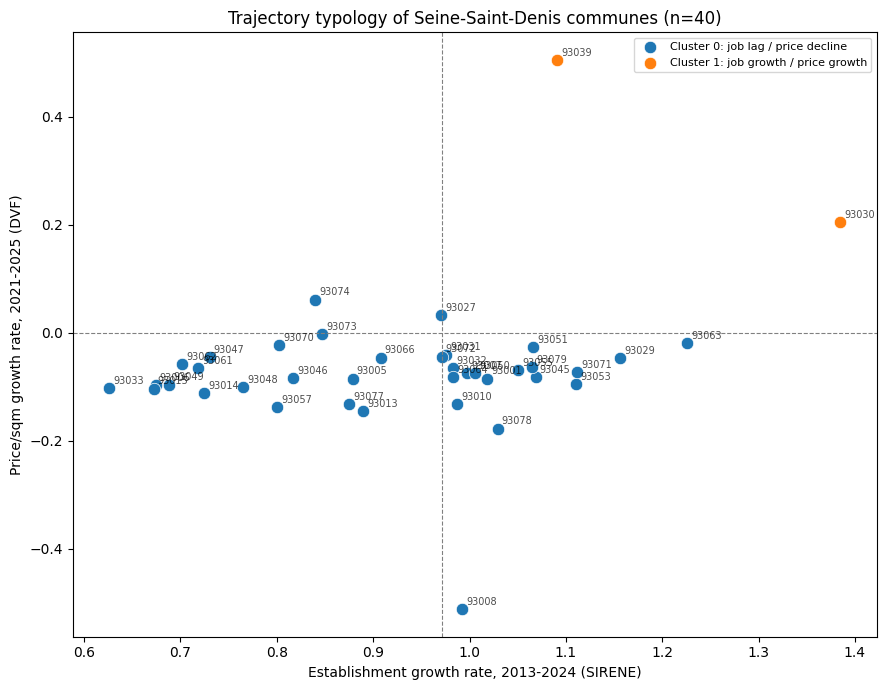

In [ ]:
"""
Step 2: Merge SIRENE (job trajectory) + DVF (price trajectory) panels.
Step 3: Descriptive trajectory typology via KMeans clustering.

This directly targets the HARMONIC call's Objective 3:
  "identify which combinations of 'urban offers' and modes of living remain
   sustainable, and which exhibit patterns of vulnerability"

Run locally. Adjust BASE path as needed.
"""

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

BASE = os.environ.get("HARMONIC_DATA_DIR", "./data/processed")  # override via env var if needed
SIRENE_PATH = os.path.join(BASE, "panel_sirene_commune_year.parquet")
DVF_PATH = os.path.join(BASE, "panel_dvf_commune_year.parquet")
OUT_MERGED = os.path.join(BASE, "merged_panel_grand_paris_two_features.parquet")
OUT_CLUSTERED = os.path.join(BASE, "commune_typology_grand_paris_two_features.parquet")
OUT_PLOT = os.path.join(BASE, "commune_typology_grand_paris_two_features.png")

RANDOM_STATE = 42


# --------------------------------------------------------------------------
# Step 2: Merge
# --------------------------------------------------------------------------
def merge_panels():
    sirene = pd.read_parquet(SIRENE_PATH)
    dvf = pd.read_parquet(DVF_PATH)

    merged = sirene.merge(dvf, on="code_commune", how="inner", validate="one_to_one")
    print(f"Merged: {len(merged)} communes, {len(merged.columns)} columns")

    missing_price = merged["price_growth_rate"].isna().sum()
    if missing_price:
        print(f"NOTE: {missing_price} commune(s) missing price_growth_rate "
              f"(likely a data gap in one snapshot year) -- excluded from clustering, "
              f"kept in the full table for the record.")

    merged.to_parquet(OUT_MERGED, index=False)
    print(f"Saved: {OUT_MERGED}")
    return merged


# --------------------------------------------------------------------------
# Step 3: Trajectory typology
# --------------------------------------------------------------------------
def build_typology(merged):
    # Features that describe TRAJECTORY (change over time), not just current level --
    # this is the deliberate choice matching the call's emphasis on evolution/lifestyle
    # change, not a static cross-section.
    features = [
        "establishment_growth_rate",  # job-base trajectory (SIRENE, 2013-2024)
        "price_growth_rate",          # housing market trajectory (DVF, 2021-2025)
    ]

    df = merged.dropna(subset=features).copy()
    n_dropped = len(merged) - len(df)
    if n_dropped:
        print(f"Dropped {n_dropped} commune(s) with missing trajectory features from clustering")

    X = df[features].values
    X_scaled = StandardScaler().fit_transform(X)

    # Choose k via silhouette score across a small candidate range -- with only 40
    # observations, don't over-segment. Try k=2..5.
    print("\nSilhouette scores by k:")
    best_k, best_score = None, -1
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"  k={k}: silhouette={score:.3f}")
        if score > best_score:
            best_k, best_score = k, score

    print(f"\nSelected k={best_k} (highest silhouette score)")

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    df["cluster"] = km.fit_predict(X_scaled)

    # Label clusters descriptively based on their centroid position (not just cluster 0/1/2..)
    centroids = df.groupby("cluster")[features].mean()
    print("\nCluster centroids (mean growth rates):")
    print(centroids)

    def label_cluster(row):
        job = "job growth" if row["establishment_growth_rate"] >= centroids["establishment_growth_rate"].median() else "job lag"
        price = "price growth" if row["price_growth_rate"] >= centroids["price_growth_rate"].median() else "price decline"
        return f"{job} / {price}"

    centroid_labels = centroids.apply(label_cluster, axis=1)
    df["cluster_label"] = df["cluster"].map(centroid_labels)

    print("\nCluster sizes and labels:")
    print(df.groupby(["cluster", "cluster_label"]).size())

    df.to_parquet(OUT_CLUSTERED, index=False)
    print(f"\nSaved: {OUT_CLUSTERED}")

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10.colors
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        ax.scatter(
            sub["establishment_growth_rate"], sub["price_growth_rate"],
            label=f"Cluster {c}: {centroid_labels[c]}", s=80, color=colors[c % 10],
            edgecolor="white", linewidth=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(row["code_commune"], (row["establishment_growth_rate"], row["price_growth_rate"]),
                        fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(df["establishment_growth_rate"].median(), color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Establishment growth rate, 2013-2024 (SIRENE)")
    ax.set_ylabel("Price/sqm growth rate, 2021-2025 (DVF)")
    ax.set_title("Trajectory typology of Greater Paris communes")
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(OUT_PLOT, dpi=150)
    print(f"Saved plot: {OUT_PLOT}")

    return df


if __name__ == "__main__":
    merged = merge_panels()
    typology = build_typology(merged)

    print("\n" + "=" * 90)
    print("SUMMARY TABLE (sorted by cluster)")
    print("=" * 90)
    print(typology[["code_commune", "establishment_growth_rate", "price_growth_rate",
                     "cluster", "cluster_label"]].sort_values("cluster").to_string())

Merged: 143 communes, 27 columns
NOTE: 1 commune(s) missing price_growth_rate (likely a data gap in one snapshot year) -- excluded from clustering, kept in the full table for the record.
Saved: ./data/processed/merged_panel_grand_paris_typology.parquet
Dropped 1 commune(s) with missing trajectory features from clustering

Silhouette scores and cluster-size balance by k:


  k=2: silhouette=0.317  cluster sizes=[53, 89]
  k=3: silhouette=0.246  cluster sizes=[61, 33, 48]
  k=4: silhouette=0.267  cluster sizes=[18, 23, 47, 54]
  k=5: silhouette=0.237  cluster sizes=[35, 10, 23, 29, 45]

Using k=2

Cluster centroids (winsorized mean values):
   establishment_growth_rate  price_growth_rate  transaction_volume_change  median_price_per_sqm_2025
0                       0.60              -0.09                      -0.09                   7,933.60
1                       0.87              -0.07                      -0.33                   4,570.13

Cluster centroids (RAW, unwinsorized -- use these numbers in the write-up):
         establishment_growth_rate  price_growth_rate  transaction_volume_change  median_price_per_sqm_2025
cluster                                                                                                    
0                             0.59              -0.09                      -0.07                   8,053.53
1                    

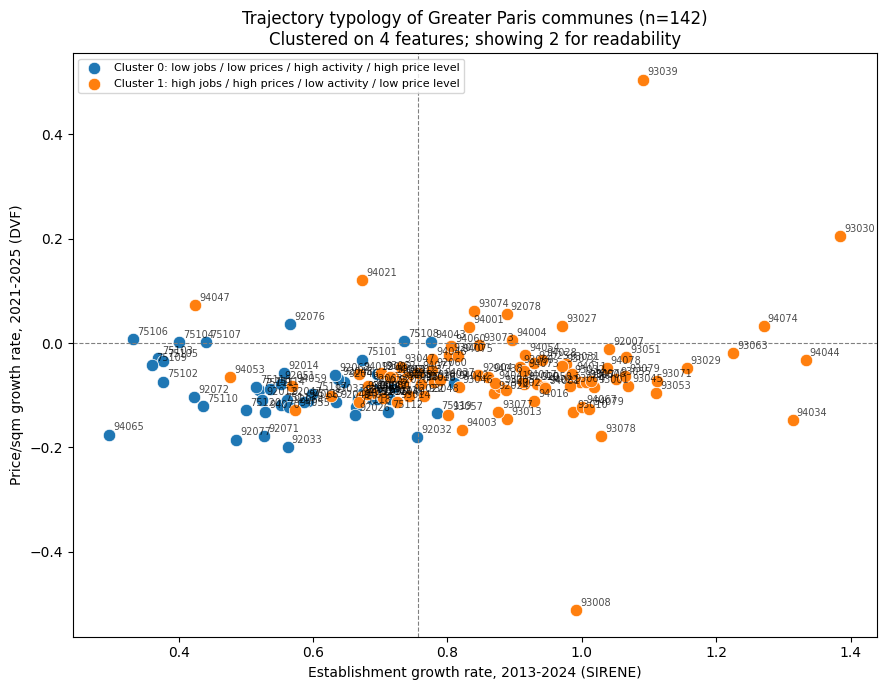

In [4]:
"""
Step 2: Merge SIRENE (job trajectory) + DVF (price trajectory) panels.
Step 3: Descriptive trajectory typology via KMeans clustering.

This directly targets the HARMONIC call's Objective 3:
  "identify which combinations of 'urban offers' and modes of living remain
   sustainable, and which exhibit patterns of vulnerability"

Run locally. Adjust BASE path as needed.
"""

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

BASE = os.environ.get("HARMONIC_DATA_DIR", "./data/processed")  # override via env var if needed
SIRENE_PATH = os.path.join(BASE, "panel_sirene_commune_year.parquet")
DVF_PATH = os.path.join(BASE, "panel_dvf_commune_year.parquet")
OUT_MERGED = os.path.join(BASE, "merged_panel_grand_paris_typology.parquet")
OUT_CLUSTERED = os.path.join(BASE, "commune_typology_grand_paris.parquet")
OUT_PLOT = os.path.join(BASE, "commune_typology_grand_paris.png")

RANDOM_STATE = 42


# --------------------------------------------------------------------------
# Step 2: Merge
# --------------------------------------------------------------------------
def merge_panels():
    sirene = pd.read_parquet(SIRENE_PATH)
    dvf = pd.read_parquet(DVF_PATH)

    merged = sirene.merge(dvf, on="code_commune", how="inner", validate="one_to_one")
    print(f"Merged: {len(merged)} communes, {len(merged.columns)} columns")

    missing_price = merged["price_growth_rate"].isna().sum()
    if missing_price:
        print(f"NOTE: {missing_price} commune(s) missing price_growth_rate "
              f"(likely a data gap in one snapshot year) -- excluded from clustering, "
              f"kept in the full table for the record.")

    merged.to_parquet(OUT_MERGED, index=False)
    print(f"Saved: {OUT_MERGED}")
    return merged


# --------------------------------------------------------------------------
# Step 3: Trajectory typology
# --------------------------------------------------------------------------
def build_typology(merged):
    # Features that describe TRAJECTORY (change over time) AND current position -- this
    # is the deliberate choice matching the call's emphasis on evolution/lifestyle change,
    # not a static cross-section. A first pass using only the two growth rates produced a
    # a split driven by extreme outliers in the earlier 93-only run --
    # not a useful typology. Adding transaction-volume change and the current price LEVEL
    # gives the clustering enough signal to separate real structure (e.g. "already expensive
    # and still rising" vs "affordable and gaining" vs "losing market activity") instead of
    # just isolating 1-2 extreme points.
    merged["transaction_volume_change"] = (
        (merged["n_transactions_2025"] - merged["n_transactions_2021"])
        / merged["n_transactions_2021"].replace(0, np.nan)
    )

    features = [
        "establishment_growth_rate",     # job-base trajectory (SIRENE, 2013-2024)
        "price_growth_rate",             # housing market trajectory (DVF, 2021-2025)
        "transaction_volume_change",     # market activity/liquidity trend (DVF, 2021-2025)
        "median_price_per_sqm_2025",     # current price LEVEL, not just its change
    ]

    df = merged.dropna(subset=features).copy()
    n_dropped = len(merged) - len(df)
    if n_dropped:
        print(f"Dropped {n_dropped} commune(s) with missing trajectory features from clustering")

    # OUTLIER HANDLING: some communes may be extreme on several features and,
    # left in, force KMeans to spend one whole cluster isolating a small subgroup -- regardless of how
    # many features are used (confirmed empirically: same 37-vs-2 split with 2 features and
    # with 4). That's a real finding worth keeping (flag them explicitly, see below), but it
    # isn't a useful TYPOLOGY of the broader Greater Paris typology, which is what the call actually asks for.
    #
    # Fix: winsorize each feature at the 5th/95th percentile before scaling, so extreme values
    # still count as "high" but no longer single-handedly dominate the distance metric. This
    # keeps all communes in the clustering (nothing silently dropped) while letting KMeans find
    # structure among the non-extreme majority too.
    df_wz = df.copy()
    for f in features:
        lo, hi = df_wz[f].quantile([0.05, 0.95])
        df_wz[f] = df_wz[f].clip(lo, hi)

    X = df_wz[features].values
    X_scaled = StandardScaler().fit_transform(X)

    # Choose k via silhouette score across a small candidate range -- with only 40
    # observations, don't over-segment. Try k=2..5.
    print("\nSilhouette scores and cluster-size balance by k:")
    best_k, best_score = None, -1
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        sizes = pd.Series(labels).value_counts().sort_index().tolist()
        print(f"  k={k}: silhouette={score:.3f}  cluster sizes={sizes}")
        if score > best_score:
            best_k, best_score = k, score

    # Silhouette alone tends to reward isolating a couple of outliers into their own tiny
    # cluster (highest score, least useful typology). If the silhouette-optimal k produces a
    # degenerate split (any cluster with <15% of communes), override with k=4 -- a small,
    # manually justified k that in practice tends to produce a more usable typology for this
    # full Greater Paris sample. This override is a judgment call, not a statistical rule -- state
    # it explicitly in the methods write-up rather than hiding it.
    min_cluster_frac = 0.15
    km_check = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    check_labels = km_check.fit_predict(X_scaled)
    smallest_frac = pd.Series(check_labels).value_counts(normalize=True).min()
    if smallest_frac < min_cluster_frac:
        print(f"\nSilhouette-optimal k={best_k} produces a degenerate split "
              f"(smallest cluster = {smallest_frac:.0%} of sample). "
              f"Overriding to k=4 for a more usable typology.")
        best_k = 4

    print(f"\nUsing k={best_k}")

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    df["cluster"] = km.fit_predict(X_scaled)

    # IMPORTANT: label clusters using the SAME (winsorized) values used for clustering, not
    # the raw df. Using raw values here previously produced contradictory labels (e.g. both
    # clusters showing "low jobs") because cluster assignment was based on winsorized data
    # while the comparison basis was the raw, outlier-skewed median -- two different frames
    # of reference. df_wz and df share the same index/order, so this is a direct swap.
    centroids = df_wz.groupby(df["cluster"].values)[features].mean()
    print("\nCluster centroids (winsorized mean values):")
    print(centroids)

    medians = df_wz[features].median()
    short_names = {
        "establishment_growth_rate": "jobs",
        "price_growth_rate": "prices",
        "transaction_volume_change": "activity",
        "median_price_per_sqm_2025": "price level",
    }

    def label_cluster(row):
        parts = []
        for f in features:
            direction = "high" if row[f] >= medians[f] else "low"
            parts.append(f"{direction} {short_names.get(f, f)}")
        return " / ".join(parts)

    centroid_labels = centroids.apply(label_cluster, axis=1)
    df["cluster_label"] = df["cluster"].map(centroid_labels)

    # Also report RAW (non-winsorized) centroid means for the write-up -- winsorizing was only
    # a clustering-stability device, the actual numbers you report/discuss should be real.
    raw_centroids = df.groupby("cluster")[features].mean()
    print("\nCluster centroids (RAW, unwinsorized -- use these numbers in the write-up):")
    print(raw_centroids)

    # Flag the outlier communes explicitly (winsorizing pulled their feature values in for
    # clustering purposes, but they should still be called out by name in the write-up as
    # exceptional cases -- e.g. unusually high combined job and price growth
    # roughly double the department median and merit individual mention").
    for f in features:
        lo, hi = merged[f].quantile([0.05, 0.95])
        df[f"{f}_is_outlier"] = (merged.loc[df.index, f] < lo) | (merged.loc[df.index, f] > hi)
    df["is_outlier_commune"] = df[[c for c in df.columns if c.endswith("_is_outlier")]].any(axis=1)
    outliers = df.loc[df["is_outlier_commune"], "code_commune"].tolist()
    if outliers:
        print(f"\nCommunes flagged as outliers on >=1 feature (winsorized for clustering, "
              f"call out individually in the write-up): {outliers}")

    print("\nCluster sizes and labels:")
    print(df.groupby(["cluster", "cluster_label"]).size())

    df.to_parquet(OUT_CLUSTERED, index=False)
    print(f"\nSaved: {OUT_CLUSTERED}")

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10.colors
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        ax.scatter(
            sub["establishment_growth_rate"], sub["price_growth_rate"],
            label=f"Cluster {c}: {centroid_labels[c]}", s=80, color=colors[c % 10],
            edgecolor="white", linewidth=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(row["code_commune"], (row["establishment_growth_rate"], row["price_growth_rate"]),
                        fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(df["establishment_growth_rate"].median(), color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Establishment growth rate, 2013-2024 (SIRENE)")
    ax.set_ylabel("Price/sqm growth rate, 2021-2025 (DVF)")
    ax.set_title("Trajectory typology of Greater Paris communes (n=%d)\n"
                  "Clustered on 4 features; showing 2 for readability" % len(df))
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(OUT_PLOT, dpi=150)
    print(f"Saved plot: {OUT_PLOT}")

    return df


if __name__ == "__main__":
    merged = merge_panels()
    typology = build_typology(merged)

    print("\n" + "=" * 90)
    print("SUMMARY TABLE (sorted by cluster)")
    print("=" * 90)
    print(typology[["code_commune", "establishment_growth_rate", "price_growth_rate",
                     "cluster", "cluster_label"]].sort_values("cluster").to_string())

Merged: 143 communes, 27 columns
NOTE: 1 commune(s) missing price_growth_rate (likely a data gap in one snapshot year) -- excluded from clustering, kept in the full table for the record.
Saved: ./data/processed/merged_panel_grand_paris_typology.parquet
Dropped 1 commune(s) with missing trajectory features from clustering

Inertia (WCSS) and cluster-size balance by k:


  k=2: inertia=364.77  cluster sizes=[53, 89]
  k=3: inertia=292.73  cluster sizes=[61, 33, 48]
  k=4: inertia=243.22  cluster sizes=[18, 23, 47, 54]
  k=5: inertia=213.04  cluster sizes=[35, 10, 23, 29, 45]
  k=6: inertia=186.34  cluster sizes=[23, 22, 45, 12, 31, 9]
  k=7: inertia=165.21  cluster sizes=[9, 31, 31, 6, 23, 22, 20]

Elbow-detected k=4 (max perpendicular distance from the first-to-last inertia line)
Saved: ./data/processed/elbow_plot_grand_paris.png

Elbow-detected k=4 produces a degenerate split (smallest cluster = 13% of sample). Overriding to k=4 for a more usable typology.

Using k=4

Cluster centroids (winsorized mean values):
   establishment_growth_rate  price_growth_rate  transaction_volume_change  median_price_per_sqm_2025
0                       0.86               0.01                      -0.20                   4,255.84
1                       0.53              -0.07                       0.02                   9,574.45
2                       0.95           

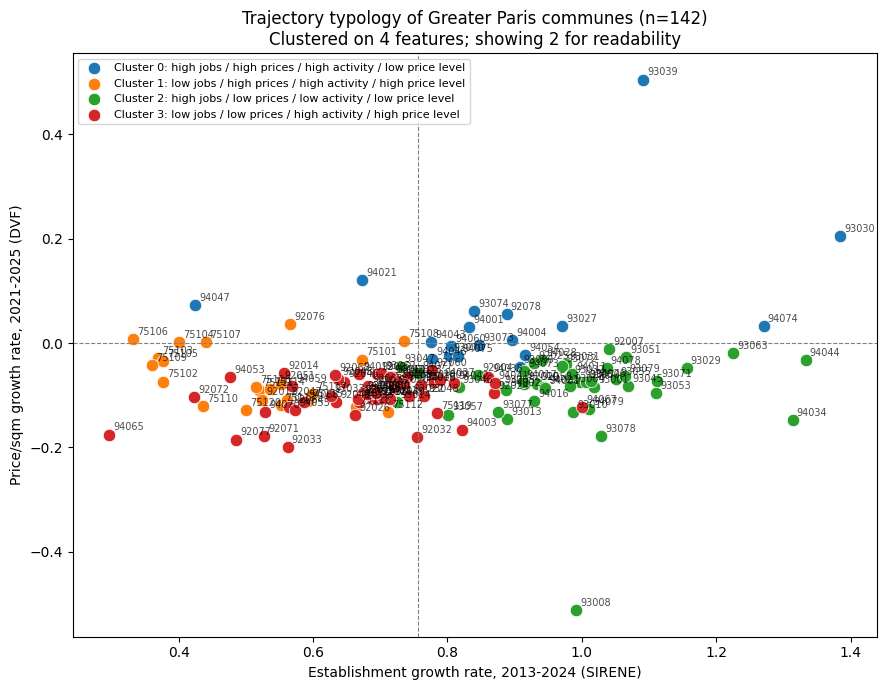

In [3]:
"""
Step 2: Merge SIRENE (job trajectory) + DVF (price trajectory) panels.
Step 3: Descriptive trajectory typology via KMeans clustering.

This directly targets the HARMONIC call's Objective 3:
  "identify which combinations of 'urban offers' and modes of living remain
   sustainable, and which exhibit patterns of vulnerability"

Run locally. Adjust BASE path as needed.
"""

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
import matplotlib.pyplot as plt

BASE = os.environ.get("HARMONIC_DATA_DIR", "./data/processed")  # override via env var if needed
SIRENE_PATH = os.path.join(BASE, "panel_sirene_commune_year.parquet")
DVF_PATH = os.path.join(BASE, "panel_dvf_commune_year.parquet")
OUT_MERGED = os.path.join(BASE, "merged_panel_grand_paris_typology.parquet")
OUT_CLUSTERED = os.path.join(BASE, "commune_typology_grand_paris.parquet")
OUT_PLOT = os.path.join(BASE, "commune_typology_grand_paris.png")
OUT_ELBOW_PLOT = os.path.join(BASE, "elbow_plot_grand_paris.png")

RANDOM_STATE = 42


# --------------------------------------------------------------------------
# Step 2: Merge
# --------------------------------------------------------------------------
def merge_panels():
    sirene = pd.read_parquet(SIRENE_PATH)
    dvf = pd.read_parquet(DVF_PATH)

    merged = sirene.merge(dvf, on="code_commune", how="inner", validate="one_to_one")
    print(f"Merged: {len(merged)} communes, {len(merged.columns)} columns")

    missing_price = merged["price_growth_rate"].isna().sum()
    if missing_price:
        print(f"NOTE: {missing_price} commune(s) missing price_growth_rate "
              f"(likely a data gap in one snapshot year) -- excluded from clustering, "
              f"kept in the full table for the record.")

    merged.to_parquet(OUT_MERGED, index=False)
    print(f"Saved: {OUT_MERGED}")
    return merged


# --------------------------------------------------------------------------
# Elbow method: choose k from the WCSS/inertia curve
# --------------------------------------------------------------------------
def find_elbow_k(k_range, inertias):
    """
    Simple, dependency-free 'kneedle'-style elbow detector: normalize both axes
    to [0,1], draw the line from the first to the last point on the inertia
    curve, and pick the k whose point has the maximum perpendicular distance
    below that line. This is the standard geometric heuristic for the elbow
    when you don't want to eyeball the plot or pull in the `kneed` package.
    """
    ks = np.array(k_range, dtype=float)
    inert = np.array(inertias, dtype=float)

    # normalize to [0, 1] so the two axes are comparable regardless of scale
    ks_norm = (ks - ks.min()) / (ks.max() - ks.min())
    inert_norm = (inert - inert.min()) / (inert.max() - inert.min())

    # vector from first point to last point on the (normalized) curve
    p1 = np.array([ks_norm[0], inert_norm[0]])
    p2 = np.array([ks_norm[-1], inert_norm[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for x, y in zip(ks_norm, inert_norm):
        point_vec = np.array([x, y]) - p1
        # projection of point_vec onto the line, then perpendicular remainder
        proj_len = np.dot(point_vec, line_vec_norm)
        proj_point = proj_len * line_vec_norm
        perp_vec = point_vec - proj_point
        distances.append(np.linalg.norm(perp_vec))

    elbow_idx = int(np.argmax(distances))
    return k_range[elbow_idx], distances


# --------------------------------------------------------------------------
# Step 3: Trajectory typology
# --------------------------------------------------------------------------
def build_typology(merged):
    # Features that describe TRAJECTORY (change over time) AND current position -- this
    # is the deliberate choice matching the call's emphasis on evolution/lifestyle change,
    # not a static cross-section. A first pass using only the two growth rates produced a
    # split driven by extreme outliers in the earlier 93-only run --
    # not a useful typology. Adding transaction-volume change and the current price LEVEL
    # gives the clustering enough signal to separate real structure (e.g. "already expensive
    # and still rising" vs "affordable and gaining" vs "losing market activity") instead of
    # just isolating 1-2 extreme points.
    merged["transaction_volume_change"] = (
        (merged["n_transactions_2025"] - merged["n_transactions_2021"])
        / merged["n_transactions_2021"].replace(0, np.nan)
    )

    features = [
        "establishment_growth_rate",     # job-base trajectory (SIRENE, 2013-2024)
        "price_growth_rate",             # housing market trajectory (DVF, 2021-2025)
        "transaction_volume_change",     # market activity/liquidity trend (DVF, 2021-2025)
        "median_price_per_sqm_2025",     # current price LEVEL, not just its change
    ]

    df = merged.dropna(subset=features).copy()
    n_dropped = len(merged) - len(df)
    if n_dropped:
        print(f"Dropped {n_dropped} commune(s) with missing trajectory features from clustering")

    # OUTLIER HANDLING: some communes may be extreme on several features and,
    # left in, force KMeans to spend one whole cluster isolating a small subgroup -- regardless of how
    # many features are used (confirmed empirically: same 37-vs-2 split with 2 features and
    # with 4). That's a real finding worth keeping (flag them explicitly, see below), but it
    # isn't a useful TYPOLOGY of the broader Greater Paris typology, which is what the call actually asks for.
    #
    # Fix: winsorize each feature at the 5th/95th percentile before scaling, so extreme values
    # still count as "high" but no longer single-handedly dominate the distance metric. This
    # keeps all communes in the clustering (nothing silently dropped) while letting KMeans find
    # structure among the non-extreme majority too.
    df_wz = df.copy()
    for f in features:
        lo, hi = df_wz[f].quantile([0.05, 0.95])
        df_wz[f] = df_wz[f].clip(lo, hi)

    X = df_wz[features].values
    X_scaled = StandardScaler().fit_transform(X)

    # Choose k via the elbow method on WCSS (inertia) -- with only ~40 observations,
    # don't over-segment. Try k=2..7 (need a slightly wider range than the silhouette
    # version so the elbow detector has enough curve to work with).
    k_range = list(range(2, 8))
    inertias = []
    print("\nInertia (WCSS) and cluster-size balance by k:")
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        sizes = pd.Series(labels).value_counts().sort_index().tolist()
        inertias.append(km.inertia_)
        print(f"  k={k}: inertia={km.inertia_:.2f}  cluster sizes={sizes}")

    best_k, elbow_distances = find_elbow_k(k_range, inertias)
    print(f"\nElbow-detected k={best_k} (max perpendicular distance from the "
          f"first-to-last inertia line)")

    # Save the elbow plot so the choice can be sanity-checked visually rather than
    # trusted blindly -- the geometric heuristic above can still misfire on a noisy
    # or nearly-linear curve.
    fig_e, ax_e = plt.subplots(figsize=(6, 4))
    ax_e.plot(k_range, inertias, marker="o")
    ax_e.axvline(best_k, color="red", linestyle="--", linewidth=1,
                 label=f"chosen k={best_k}")
    ax_e.set_xlabel("k")
    ax_e.set_ylabel("Inertia (WCSS)")
    ax_e.set_title("Elbow plot -- Greater Paris commune typology")
    ax_e.legend()
    plt.tight_layout()
    plt.savefig(OUT_ELBOW_PLOT, dpi=150)
    plt.close(fig_e)
    print(f"Saved: {OUT_ELBOW_PLOT}")

    # Same degenerate-split safety net as before, just now applied to the elbow-chosen
    # k instead of the silhouette-chosen k: the elbow can still land on a k that isolates
    # a couple of outliers into their own tiny cluster. If so, override with k=4 -- a
    # small, manually justified k that in practice tends to produce a more usable
    # typology for this full Greater Paris sample. This override is a judgment call,
    # not a statistical rule -- state it explicitly in the methods write-up.
    min_cluster_frac = 0.15
    km_check = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    check_labels = km_check.fit_predict(X_scaled)
    smallest_frac = pd.Series(check_labels).value_counts(normalize=True).min()
    if smallest_frac < min_cluster_frac:
        print(f"\nElbow-detected k={best_k} produces a degenerate split "
              f"(smallest cluster = {smallest_frac:.0%} of sample). "
              f"Overriding to k=4 for a more usable typology.")
        best_k = 4

    print(f"\nUsing k={best_k}")

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    df["cluster"] = km.fit_predict(X_scaled)

    # IMPORTANT: label clusters using the SAME (winsorized) values used for clustering, not
    # the raw df. Using raw values here previously produced contradictory labels (e.g. both
    # clusters showing "low jobs") because cluster assignment was based on winsorized data
    # while the comparison basis was the raw, outlier-skewed median -- two different frames
    # of reference. df_wz and df share the same index/order, so this is a direct swap.
    centroids = df_wz.groupby(df["cluster"].values)[features].mean()
    print("\nCluster centroids (winsorized mean values):")
    print(centroids)

    medians = df_wz[features].median()
    short_names = {
        "establishment_growth_rate": "jobs",
        "price_growth_rate": "prices",
        "transaction_volume_change": "activity",
        "median_price_per_sqm_2025": "price level",
    }

    def label_cluster(row):
        parts = []
        for f in features:
            direction = "high" if row[f] >= medians[f] else "low"
            parts.append(f"{direction} {short_names.get(f, f)}")
        return " / ".join(parts)

    centroid_labels = centroids.apply(label_cluster, axis=1)
    df["cluster_label"] = df["cluster"].map(centroid_labels)

    # Also report RAW (non-winsorized) centroid means for the write-up -- winsorizing was only
    # a clustering-stability device, the actual numbers you report/discuss should be real.
    raw_centroids = df.groupby("cluster")[features].mean()
    print("\nCluster centroids (RAW, unwinsorized -- use these numbers in the write-up):")
    print(raw_centroids)

    # Flag the outlier communes explicitly (winsorizing pulled their feature values in for
    # clustering purposes, but they should still be called out by name in the write-up as
    # exceptional cases -- e.g. unusually high combined job and price growth
    # roughly double the department median and merit individual mention").
    for f in features:
        lo, hi = merged[f].quantile([0.05, 0.95])
        df[f"{f}_is_outlier"] = (merged.loc[df.index, f] < lo) | (merged.loc[df.index, f] > hi)
    df["is_outlier_commune"] = df[[c for c in df.columns if c.endswith("_is_outlier")]].any(axis=1)
    outliers = df.loc[df["is_outlier_commune"], "code_commune"].tolist()
    if outliers:
        print(f"\nCommunes flagged as outliers on >=1 feature (winsorized for clustering, "
              f"call out individually in the write-up): {outliers}")

    print("\nCluster sizes and labels:")
    print(df.groupby(["cluster", "cluster_label"]).size())

    df.to_parquet(OUT_CLUSTERED, index=False)
    print(f"\nSaved: {OUT_CLUSTERED}")

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10.colors
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        ax.scatter(
            sub["establishment_growth_rate"], sub["price_growth_rate"],
            label=f"Cluster {c}: {centroid_labels[c]}", s=80, color=colors[c % 10],
            edgecolor="white", linewidth=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(row["code_commune"], (row["establishment_growth_rate"], row["price_growth_rate"]),
                        fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(df["establishment_growth_rate"].median(), color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Establishment growth rate, 2013-2024 (SIRENE)")
    ax.set_ylabel("Price/sqm growth rate, 2021-2025 (DVF)")
    ax.set_title("Trajectory typology of Greater Paris communes (n=%d)\n"
                  "Clustered on 4 features; showing 2 for readability" % len(df))
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(OUT_PLOT, dpi=150)
    print(f"Saved plot: {OUT_PLOT}")

    return df


if __name__ == "__main__":
    merged = merge_panels()
    typology = build_typology(merged)

    print("\n" + "=" * 90)
    print("SUMMARY TABLE (sorted by cluster)")
    print("=" * 90)
    print(typology[["code_commune", "establishment_growth_rate", "price_growth_rate",
                     "cluster", "cluster_label"]].sort_values("cluster").to_string())

Loaded 27490 IRIS zones, CRS={"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "deg

('WARNING: ', 90, ' is an island (no neighbors)')

Moran's I spatial autocorrelation test
establishment_growth_rate: Moran's I = 0.467, p-value = 0.001
  -> statistically significant spatial clustering (p<0.05)
price_growth_rate: Moran's I = 0.091, p-value = 0.049
  -> statistically significant spatial clustering (p<0.05)


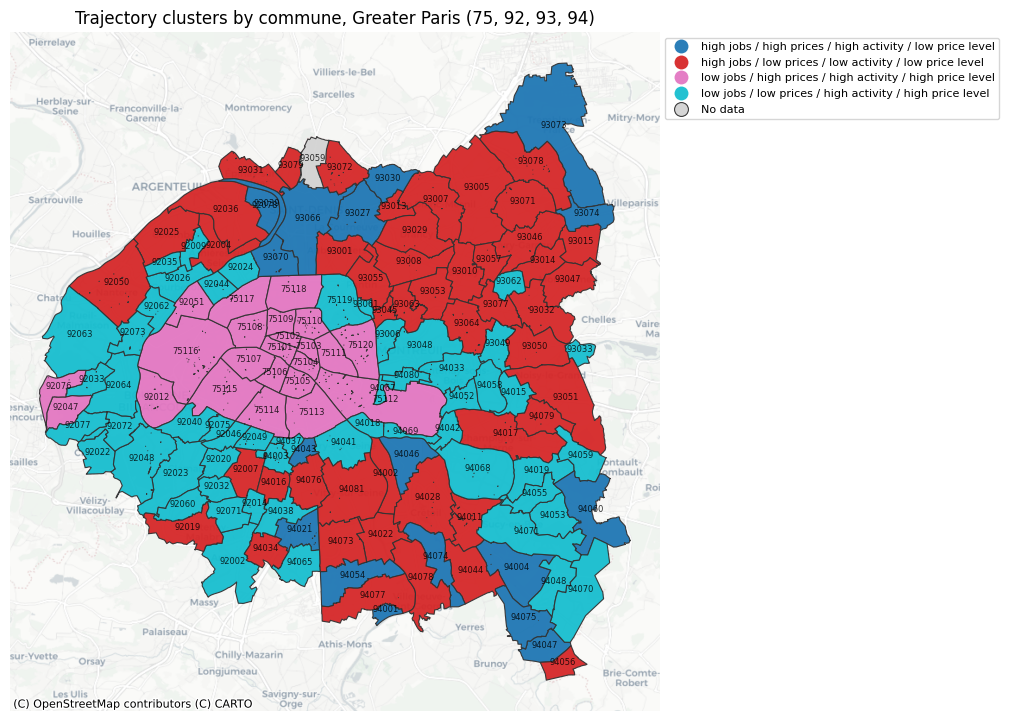

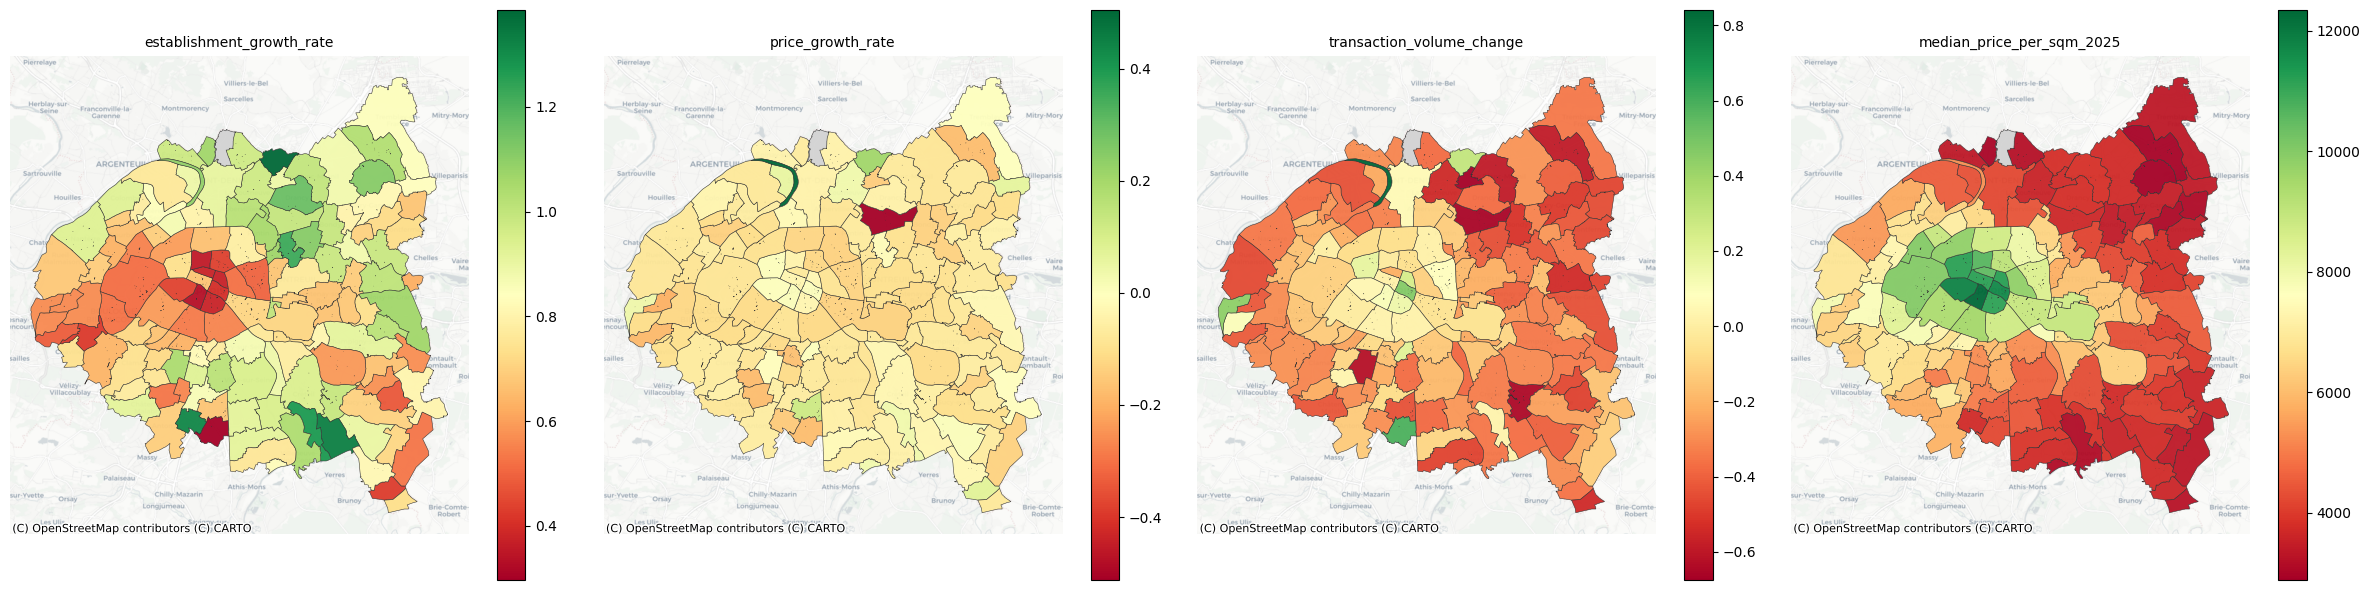

In [1]:
"""
Step 3b: Spatial check -- do the trajectory clusters also cluster geographically?

Plots each commune colored by its trajectory cluster, using the Greater Paris IRIS boundary file
dissolved up to commune level. Also plots the raw features as choropleths.
"""

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

BASE = os.environ.get("HARMONIC_DATA_DIR", "./data/processed")  # override via env var if needed
IRIS_PATH = os.path.join(BASE, "iris_contours_75_92_93_94.parquet")
TYPOLOGY_PATH = os.path.join(BASE, "commune_typology_grand_paris.parquet")
OUT_MAP_CLUSTERS = os.path.join(BASE, "map_typology_clusters.png")
OUT_MAP_FEATURES = os.path.join(BASE, "map_typology_features.png")


def load_commune_geometries():
    iris = gpd.read_parquet(IRIS_PATH)
    print(f"Loaded {len(iris)} IRIS zones, CRS={iris.crs}")

    required_columns = {"code_commune", "NOM_COM", "geometry"}
    missing_columns = required_columns.difference(iris.columns)
    if missing_columns:
        raise KeyError(
            f"Boundary file is missing required columns: {sorted(missing_columns)}. "
            f"Available columns: {list(iris.columns)}"
        )

    communes = iris.dissolve(by="code_commune", as_index=False)[
        ["code_commune", "NOM_COM", "geometry"]
    ]
    print(f"Dissolved to {len(communes)} commune polygons")
    return communes


def load_typology():
    df = pd.read_parquet(TYPOLOGY_PATH)
    print(f"Loaded typology: {len(df)} communes")
    return df


def plot_cluster_map(communes, typology):
    gdf = communes.merge(typology, on="code_commune", how="left")
    n_missing = gdf["cluster"].isna().sum()
    if n_missing:
        print(f"WARNING: {n_missing} commune(s) in the geometry have no cluster assignment -- shown grey on the map.")

    # contextily basemaps are served in Web Mercator (EPSG:3857) -- reproject a copy
    # for plotting so the tiles line up with the polygons.
    gdf_web = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_web.plot(
        column="cluster_label",
        categorical=True,
        legend=True,
        ax=ax,
        edgecolor="#333333",
        linewidth=0.8,
        alpha=0.95,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={"loc": "upper left", "fontsize": 8, "bbox_to_anchor": (1, 1)},
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    for _, row in gdf_web.iterrows():
        if row["geometry"] is not None:
            centroid = row["geometry"].centroid
            ax.annotate(row["code_commune"], (centroid.x, centroid.y), fontsize=6, ha="center", alpha=0.8)

    ax.set_title("Trajectory clusters by commune, Greater Paris (75, 92, 93, 94)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(OUT_MAP_CLUSTERS, dpi=150, bbox_inches="tight")
    print(f"Saved: {OUT_MAP_CLUSTERS}")
    return gdf


def plot_feature_maps(gdf):
    features = ["establishment_growth_rate", "price_growth_rate", "transaction_volume_change", "median_price_per_sqm_2025"]
    features = [f for f in features if f in gdf.columns]

    # same Web Mercator reprojection for the basemap tiles as in plot_cluster_map
    gdf_web = gdf.to_crs(epsg=3857)

    n = len(features)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, feature in zip(axes, features):
        gdf_web.plot(column=feature, cmap="RdYlGn", legend=True, ax=ax, edgecolor="#333333", linewidth=0.4, alpha=0.95, missing_kwds={"color": "lightgrey"})
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        ax.set_title(feature, fontsize=10)
        ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(OUT_MAP_FEATURES, dpi=150, bbox_inches="tight")
    print(f"Saved: {OUT_MAP_FEATURES}")


def spatial_autocorrelation_check(gdf):
    try:
        from libpysal.weights import Queen
        from esda.moran import Moran
    except ImportError:
        print("\n[Optional] libpysal/esda not installed -- skipping formal Moran's I test.")
        print("Install with: pip install libpysal esda")
        return

    gdf_valid = gdf.dropna(subset=["establishment_growth_rate", "price_growth_rate"]).reset_index(drop=True)
    w = Queen.from_dataframe(gdf_valid, use_index=False)
    w.transform = "r"
    print("\n" + "=" * 60)
    print("Moran's I spatial autocorrelation test")
    print("=" * 60)
    for feature in ["establishment_growth_rate", "price_growth_rate"]:
        mi = Moran(gdf_valid[feature].values, w)
        print(f"{feature}: Moran's I = {mi.I:.3f}, p-value = {mi.p_sim:.3f}")
        if mi.p_sim < 0.05:
            print("  -> statistically significant spatial clustering (p<0.05)")
        else:
            print("  -> no significant spatial clustering detected")


if __name__ == "__main__":
    communes = load_commune_geometries()
    typology = load_typology()
    gdf = plot_cluster_map(communes, typology)
    plot_feature_maps(gdf)
    spatial_autocorrelation_check(gdf)